In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('D:/Data Science/Assignment 3/Global Economy Indicators.csv', on_bad_lines='skip')

In [11]:
df

,CountryID,Country,Year,AMA exchange rate,IMF based exchange rate,Population,Currency,Per capita GNI,"Agriculture, hunting, forestry, fishing (ISIC A-B)",Changes in inventories,...,Household consumption expenditure (including Non-profit institutions serving households),Imports of goods and services,Manufacturing (ISIC D),"Mining, Manufacturing, Utilities (ISIC C-E)",Other Activities (ISIC J-P),Total Value Added,"Transport, storage and communication (ISIC I)","Wholesale, retail trade, restaurants and hotels (ISIC G-H)",Gross National Income(GNI) in USD,Gross Domestic Product (GDP)
0,4,Afghanistan,1970,0.044998,0.044998,10752971,Afghani,164,8.699174e+08,NaN,...,1.551094e+09,1.952772e+08,3.701468e+08,3.766908e+08,1.277478e+08,1.731454e+09,8.391720e+07,2.263871e+08,1.766528e+09,1.731436e+09
1,4,Afghanistan,1971,0.044998,0.044998,11015857,Afghani,168,9.108281e+08,NaN,...,1.675426e+09,2.762965e+08,3.875495e+08,3.944012e+08,1.337541e+08,1.812857e+09,8.786038e+07,2.370192e+08,1.850122e+09,1.812838e+09
2,4,Afghanistan,1972,0.044998,0.044998,11286753,Afghani,149,8.279453e+08,NaN,...,1.498812e+09,2.903704e+08,3.522847e+08,3.585129e+08,1.215827e+08,1.647918e+09,7.986452e+07,2.154773e+08,1.683948e+09,1.647900e+09
3,4,Afghanistan,1973,0.044998,0.044998,11575305,Afghani,150,8.554869e+08,NaN,...,1.508024e+09,2.629629e+08,3.640103e+08,3.704458e+08,1.256302e+08,1.702735e+09,8.252888e+07,2.226243e+08,1.739998e+09,1.702716e+09
4,4,Afghanistan,1974,0.044998,0.044998,11869879,Afghani,177,1.035913e+09,NaN,...,1.778819e+09,3.056792e+08,4.407604e+08,4.485528e+08,1.521192e+08,2.061752e+09,9.991860e+07,2.695259e+08,2.106420e+09,2.061729e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10507,894,Zambia,2017,9.519501,9.519501,17298054,Kwacha,1448,1.041005e+09,567729313.0,...,1.215309e+10,9.465895e+09,2.102369e+09,7.194153e+09,6.187124e+09,2.416662e+10,1.965026e+09,5.323590e+09,2.505604e+10,2.586816e+10
10508,894,Zambia,2018,10.458143,10.458143,17835893,Kwacha,1451,8.791160e+08,929063411.0,...,1.183200e+10,9.717269e+09,1.801783e+09,6.556884e+09,5.791375e+09,2.422570e+10,2.490720e+09,5.990720e+09,2.588455e+10,2.631198e+10
10509,894,Zambia,2019,12.889418,12.889418,18380477,Kwacha,1246,6.668385e+08,817104395.0,...,9.848112e+09,7.961415e+09,1.582484e+09,5.584425e+09,5.231062e+09,2.153971e+10,2.537646e+09,4.959277e+09,2.291011e+10,2.331036e+10
10510,894,Zambia,2020,18.344093,18.344093,18927715,Kwacha,928,5.391694e+08,439295787.0,...,6.969267e+09,5.892353e+09,1.397303e+09,4.269405e+09,4.217431e+09,1.718020e+10,2.258715e+09,3.234123e+09,1.756233e+10,1.811064e+10


In [12]:
df.columns

Index([' CountryID ', ' Country ', ' Year ', ' AMA exchange rate ',
       ' IMF based exchange rate ', ' Population ', ' Currency ',
       ' Per capita GNI ',
       ' Agriculture, hunting, forestry, fishing (ISIC A-B) ',
       ' Changes in inventories ', ' Construction (ISIC F) ',
       ' Exports of goods and services ', ' Final consumption expenditure ',
       ' General government final consumption expenditure ',
       ' Gross capital formation ',
       ' Gross fixed capital formation (including Acquisitions less disposals of valuables) ',
       ' Household consumption expenditure (including Non-profit institutions serving households) ',
       ' Imports of goods and services ', ' Manufacturing (ISIC D) ',
       ' Mining, Manufacturing, Utilities (ISIC C-E) ',
       ' Other Activities (ISIC J-P) ', ' Total Value Added ',
       ' Transport, storage and communication (ISIC I) ',
       ' Wholesale, retail trade, restaurants and hotels (ISIC G-H) ',
       ' Gross National In

In [13]:
df.columns = df.columns.str.strip()

In [16]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Compute correlation matrix
corr_matrix = df[numeric_cols].corr()

# Find pairs with r >= 0.8 (excluding self-correlation)
high_corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i+1, len(numeric_cols)):
        r = corr_matrix.iloc[i, j]
        if r >= 0.8:
            high_corr_pairs.append((numeric_cols[i], numeric_cols[j], r))

# Print results
print("Pairs with correlation r >= 0.8:")
for pair in high_corr_pairs:
    print(f"{pair[0]} vs {pair[1]} -> r = {pair[2]:.3f}")

Pairs with correlation r >= 0.8:
AMA exchange rate vs IMF based exchange rate -> r = 0.948
Construction (ISIC F) vs Exports of goods and services -> r = 0.873
Construction (ISIC F) vs Final consumption expenditure -> r = 0.923
Construction (ISIC F) vs General government final consumption expenditure -> r = 0.961
Construction (ISIC F) vs Gross capital formation -> r = 0.984
Construction (ISIC F) vs Gross fixed capital formation (including Acquisitions less disposals of valuables) -> r = 0.985
Construction (ISIC F) vs Household consumption expenditure (including Non-profit institutions serving households) -> r = 0.907
Construction (ISIC F) vs Imports of goods and services -> r = 0.903
Construction (ISIC F) vs Manufacturing (ISIC D) -> r = 0.968
Construction (ISIC F) vs Mining, Manufacturing, Utilities (ISIC C-E) -> r = 0.975
Construction (ISIC F) vs Other Activities (ISIC J-P) -> r = 0.902
Construction (ISIC F) vs Total Value Added -> r = 0.963
Construction (ISIC F) vs Transport, storage

Correlation r = 0.8734868807993685


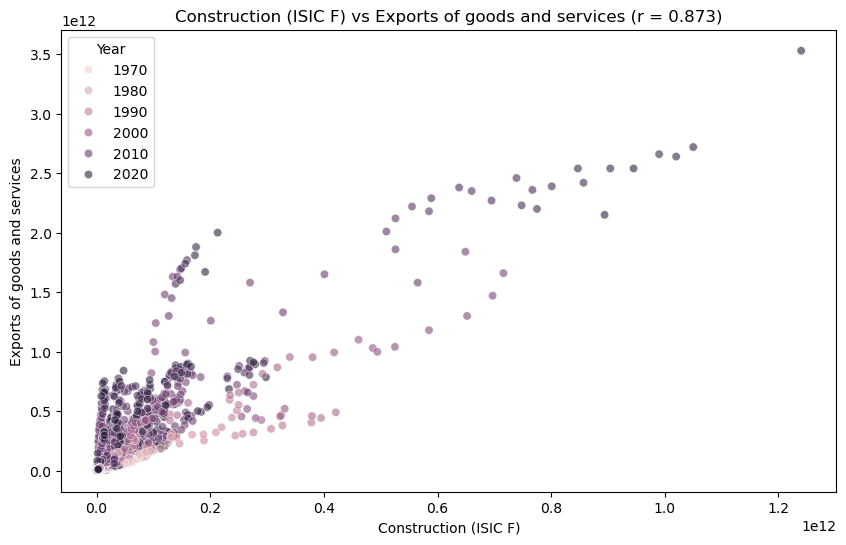

In [18]:
# Select two columns to test
x = df["Construction (ISIC F)"]
y = df["Exports of goods and services"]

# Compute correlation
r = x.corr(y)
print("Correlation r =", r)

# Scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=x, y=y, hue=df["Year"], alpha=0.6)
plt.title("Construction (ISIC F) vs Exports of goods and services (r = 0.873)")
plt.xlabel("Construction (ISIC F)")
plt.ylabel("Exports of goods and services")
plt.show()

In [25]:
df["Construction (ISIC F)"].isna().sum()

np.int64(0)

In [22]:
df["Exports of goods and services"].isna().sum()

np.int64(21)

In [24]:
from scipy import stats

data = df[["Construction (ISIC F)", "Exports of goods and services"]].dropna()
x = data["Construction (ISIC F)"]
y = data["Exports of goods and services"]

# Compute Pearson correlation and p-value
r, p_value = stats.pearsonr(x, y)
print(f"Pearson correlation: r = {r:.3f}")
print(f"P-value: {p_value:.5f}")

# Compute 95% confidence interval using Fisher's Z transformation
n = len(x)  # sample size after dropping NaNs
z = np.arctanh(r)    # Fisher's z
se = 1 / np.sqrt(n - 3)  # standard error
z_crit = 1.96  # 95% confidence level

# Confidence interval in z-space
z_lower = z - z_crit * se
z_upper = z + z_crit * se

# Transform back to r-space
r_lower = np.tanh(z_lower)
r_upper = np.tanh(z_upper)
print(f"95% Confidence Interval for r: [{r_lower:.3f}, {r_upper:.3f}]")

Pearson correlation: r = 0.873
P-value: 0.00000
95% Confidence Interval for r: [0.869, 0.878]


In [26]:
x = data["Construction (ISIC F)"].values
y = data["Exports of goods and services"].values

# Bootstrapping parameters
n_iterations = 1000
n_size = len(x)
boot_corrs = []

# Perform bootstrap
for i in range(n_iterations):
    # Sample indices with replacement
    indices = np.random.choice(n_size, size=n_size, replace=True)
    sample_x = x[indices]
    sample_y = y[indices]
    
    # Compute correlation for this bootstrap sample
    r_boot = np.corrcoef(sample_x, sample_y)[0, 1]
    boot_corrs.append(r_boot)

# Compute 95% confidence interval using percentiles
ci_lower = np.percentile(boot_corrs, 2.5)
ci_upper = np.percentile(boot_corrs, 97.5)
print(f"Bootstrap 95% CI for r: [{ci_lower:.3f}, {ci_upper:.3f}]")

# Optional: compare with observed r
observed_r = np.corrcoef(x, y)[0, 1]
print(f"Observed correlation: r = {observed_r:.3f}")

Bootstrap 95% CI for r: [0.845, 0.895]
Observed correlation: r = 0.873
